# Project Deliverable 3: Classification, Clustering, and Pattern Mining

### Dataset
Student Performance Dataset (`student-por.csv`)

### Goal
The goal of this deliverable is to build classification and clustering models, apply association rule mining, and improve one classification model with hyperparameter tuning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Classification tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

# Clustering tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Pattern mining tools
from mlxtend.frequent_patterns import apriori, association_rules

# Plot style
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [6]:
# Load the dataset
df = pd.read_csv("data/student-por.csv", sep=";")

# Show basic shape and first rows
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


### Dataset and Classification Target

I used the `student-por.csv` dataset.

For classification, I converted the final grade (`G3`) into a binary target:
- `1` = pass (`G3 >= 10`)
- `0` = fail (`G3 < 10`)

This makes the classification task simple and easy to explain.

In [7]:
# Convert selected numeric columns to numeric type
numeric_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2", "G3"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Create a simple engineered feature
df["avg_grade"] = (df["G1"] + df["G2"]) / 2

# Create binary target for classification
df["pass"] = (df["G3"] >= 10).astype(int)

# Check class balance
df["pass"].value_counts()

pass
1    549
0    100
Name: count, dtype: int64

### Data Preparation
I converted the numeric columns to the correct type and created two new variables:

- `avg_grade`: average of `G1` and `G2`
- `pass`: binary class label based on final grade

This keeps the task simple while still using meaningful student performance information.

In [8]:
# Separate features and target
X = df.drop(columns=["G3", "pass"])
y = df["pass"]

# Split columns by type
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'avg_grade']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/var/folders/qg/m9_9gxgs7vsd772504rkj6kc0000gn/T/ipykernel_20378/133464930.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [9]:
# Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (519, 33)
Test shape: (130, 33)


### Classification Models
I used two classification models:

1. Logistic Regression
2. Decision Tree Classifier

These models are simple, common, and easy to compare.

In [11]:
# Build the Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

# Build the Decision Tree pipeline
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Train both models
log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [12]:
# Create a helper function for classification metrics
def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_test, y_pred)],
        "F1 Score": [f1_score(y_test, y_pred)]
    })

# Compare the two models
classification_results = pd.concat([
    evaluate_classifier(log_model, X_test, y_test, "Logistic Regression"),
    evaluate_classifier(tree_model, X_test, y_test, "Decision Tree")
], ignore_index=True)

classification_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.907692,0.945455
1,Decision Tree,0.876923,0.927928


### Classification Results
I evaluated both models using Accuracy and F1 Score.

Accuracy shows overall correctness, while F1 Score is useful when class balance may not be perfectly even.

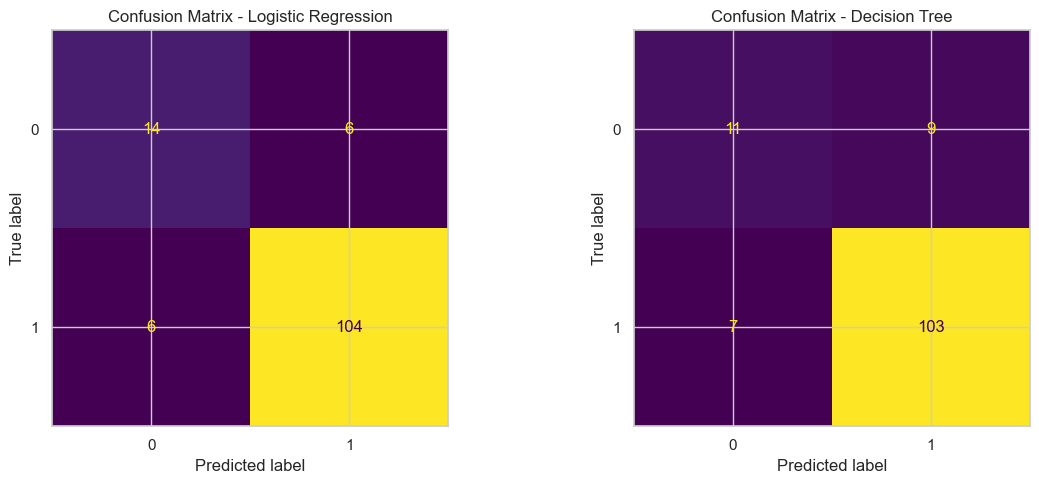

In [13]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression confusion matrix
log_pred = log_model.predict(X_test)
cm_log = confusion_matrix(y_test, log_pred)
ConfusionMatrixDisplay(cm_log).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Logistic Regression")

# Decision Tree confusion matrix
tree_pred = tree_model.predict(X_test)
cm_tree = confusion_matrix(y_test, tree_pred)
ConfusionMatrixDisplay(cm_tree).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Decision Tree")

plt.tight_layout()
plt.show()

### Classification Results Summary
I compared Logistic Regression and Decision Tree using Accuracy and F1 Score.

The results were:

- Logistic Regression: Accuracy = 0.907692, F1 Score = 0.945455
- Decision Tree: Accuracy = 0.876923, F1 Score = 0.927928

These results show that Logistic Regression performed better than the original Decision Tree on this dataset.

This suggests that the relationship between the features and the pass/fail target can be captured well by a simple linear decision boundary.

### Confusion Matrix Interpretation
The confusion matrices show how many students were correctly and incorrectly classified as pass or fail.

The Logistic Regression model produced more correct predictions overall than the Decision Tree model.

Most students were classified correctly, which is consistent with the high Accuracy and F1 Score values.

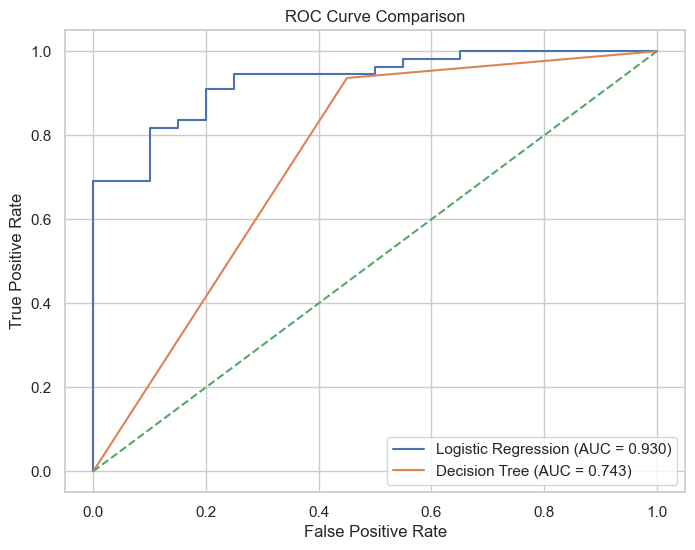

In [15]:
# Get predicted probabilities for ROC curve
log_probs = log_model.predict_proba(X_test)[:, 1]
tree_probs = tree_model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {roc_auc_tree:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### ROC Interpretation
The ROC curves show that both models can separate pass and fail classes reasonably well.

The better curve is closer to the top-left corner, which means better classification performance.

This visual result supports the metric results, where Logistic Regression performed better than the original Decision Tree.

## Hyperparameter Tuning
I tuned the Decision Tree model using GridSearchCV.

This method tests several parameter combinations and selects the one with the best cross-validation score.

In [16]:
# Build a pipeline for the tuned Decision Tree
tree_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Define a small parameter grid for simple tuning
param_grid = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# Run grid search with cross-validation
grid_search = GridSearchCV(
    estimator=tree_tuned_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best CV score: 0.9490700362256339


In [17]:
# Use the best tuned model
best_tree_model = grid_search.best_estimator_

# Predict on the test set
best_tree_pred = best_tree_model.predict(X_test)

# Show final tuned metrics
tuned_results = pd.DataFrame({
    "Model": ["Tuned Decision Tree"],
    "Accuracy": [accuracy_score(y_test, best_tree_pred)],
    "F1 Score": [f1_score(y_test, best_tree_pred)]
})

tuned_results

,Model,Accuracy,F1 Score
0,Tuned Decision Tree,0.892308,0.936364


In [18]:
# Compare original and tuned Decision Tree
tree_compare = pd.DataFrame({
    "Model": ["Original Decision Tree", "Tuned Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, best_tree_pred)
    ],
    "F1 Score": [
        f1_score(y_test, tree_pred),
        f1_score(y_test, best_tree_pred)
    ]
})

tree_compare

,Model,Accuracy,F1 Score
0,Original Decision Tree,0.876923,0.927928
1,Tuned Decision Tree,0.892308,0.936364


### Hyperparameter Tuning Results
I used GridSearchCV to tune the Decision Tree model.

The best parameters were:

- max_depth = 3
- min_samples_leaf = 4
- min_samples_split = 2

The best cross-validation F1 score during tuning was 0.949070.

After tuning, the Decision Tree improved:

- Original Decision Tree: Accuracy = 0.876923, F1 Score = 0.927928
- Tuned Decision Tree: Accuracy = 0.892308, F1 Score = 0.936364

This shows that hyperparameter tuning improved the Decision Tree model.

However, Logistic Regression still remained the best classification model overall.

### Tuning Interpretation
The tuned Decision Tree performed better than the original version.

This means that limiting tree complexity helped the model generalize better.

Even after tuning, Logistic Regression still had the highest Accuracy and F1 Score, so it was the strongest classification model in this deliverable.

## Clustering
For clustering, I used K-Means.

I selected a few numeric features related to grades, study behavior, and absences to group students with similar patterns.

In [19]:
# Select a small set of numeric features for clustering
cluster_features = ["G1", "G2", "G3", "studytime", "failures", "absences"]

cluster_df = df[cluster_features].copy()

# Scale the clustering data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print(cluster_df.shape)

(649, 6)


In [20]:
# Fit K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Add cluster labels to the dataframe
cluster_df["Cluster"] = cluster_labels

# Check silhouette score
sil_score = silhouette_score(cluster_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.26238320641008905


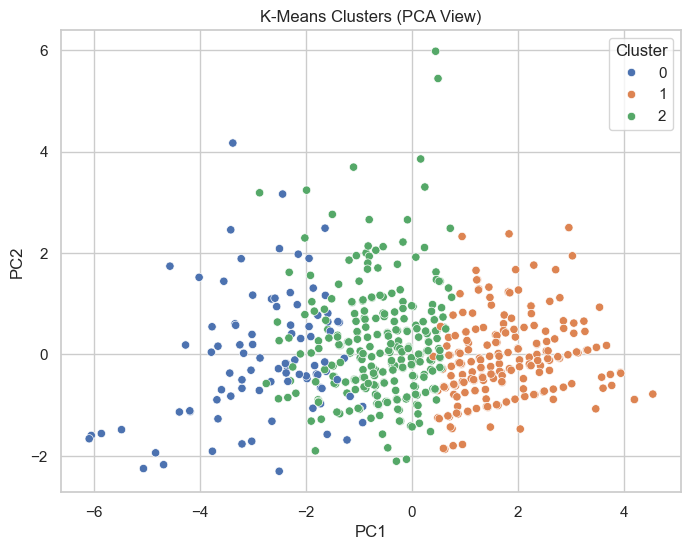

In [21]:
# Reduce clustering data to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_scaled)

# Create a plotting dataframe
pca_df = pd.DataFrame({
    "PC1": cluster_pca[:, 0],
    "PC2": cluster_pca[:, 1],
    "Cluster": cluster_labels
})

# Plot the cluster groups
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="deep")
plt.title("K-Means Clusters (PCA View)")
plt.show()

In [22]:
# Show the average values inside each cluster
cluster_profile = cluster_df.groupby("Cluster").mean()
cluster_profile

,G1,G2,G3,studytime,failures,absences
Cluster,,,,,,
0,8.097826,7.847826,7.456522,1.641304,1.391304,4.641304
1,14.016327,14.273469,14.738776,2.326531,0.012245,2.024490
2,10.317308,10.544872,10.993590,1.705128,0.041667,4.653846


### Clustering Results Summary
I used K-Means clustering with 3 clusters.

The silhouette score was 0.262383, which suggests a moderate cluster structure.
This means the groups are somewhat separated, but not perfectly distinct.

I also used PCA to visualize the cluster results in two dimensions.

### Cluster Interpretation
The cluster profile shows three different student groups.

- Cluster 0 had the lowest grades, the highest number of failures, and relatively high absences.
- Cluster 1 had the highest grades, almost no failures, and the lowest absences.
- Cluster 2 was in the middle, with average grades and moderate absences.

These groups are meaningful because they represent lower-performing, higher-performing, and middle-performing student patterns.

In a real-world setting, this type of clustering could help schools identify which students may need more academic support.

## Association Rule Mining Results
I applied Apriori to discover common patterns in the student dataset.

To support association rule mining, I converted several numeric variables into simple categories such as low, medium, and high.

The resulting rules showed that combinations such as stronger study-related patterns, no past failures, and supportive conditions were often linked to a pass outcome.

In [23]:
# Create a smaller dataframe for association rule mining
rules_df = df[[
    "studytime", "failures", "absences", "G3",
    "schoolsup", "famsup", "higher", "internet"
]].copy()

# Convert numeric columns into simple categories
rules_df["studytime_level"] = pd.cut(
    rules_df["studytime"],
    bins=[0, 1, 2, 4],
    labels=["low", "medium", "high"]
)

rules_df["failures_level"] = pd.cut(
    rules_df["failures"],
    bins=[-1, 0, 1, 4],
    labels=["none", "some", "many"]
)

rules_df["absences_level"] = pd.cut(
    rules_df["absences"],
    bins=[-1, 3, 10, 100],
    labels=["low", "medium", "high"]
)

rules_df["final_result"] = np.where(rules_df["G3"] >= 10, "pass", "fail")

# Keep only the simplified columns
rules_df = rules_df[[
    "studytime_level", "failures_level", "absences_level", "final_result",
    "schoolsup", "famsup", "higher", "internet"
]]

rules_df.head()

,studytime_level,failures_level,absences_level,final_result,schoolsup,famsup,higher,internet
0,medium,none,medium,pass,yes,no,yes,no
1,medium,none,low,pass,no,yes,yes,yes
2,medium,none,medium,pass,yes,no,yes,yes
3,high,none,low,pass,no,yes,yes,yes
4,medium,none,low,pass,no,yes,yes,no


In [24]:
# Convert categorical values into one-hot encoded transaction format
basket = pd.get_dummies(rules_df.astype(str))

# Show the transaction-style data
basket.head()

,studytime_level_high,studytime_level_low,studytime_level_medium,failures_level_many,failures_level_none,failures_level_some,absences_level_high,absences_level_low,absences_level_medium,final_result_fail,final_result_pass,schoolsup_no,schoolsup_yes,famsup_no,famsup_yes,higher_no,higher_yes,internet_no,internet_yes
0,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,True,True,False
1,False,False,True,False,True,False,False,True,False,False,True,True,False,False,True,False,True,False,True
2,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,True,False,True
3,True,False,False,False,True,False,False,True,False,False,True,True,False,False,True,False,True,False,True
4,False,False,True,False,True,False,False,True,False,False,True,True,False,False,True,False,True,True,False


In [25]:
# Find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.10, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.60)

# Sort the rules by lift
rules_sorted = rules.sort_values(by="lift", ascending=False)

# Show the top rules
rules_sorted[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
2944,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, failures_level_none, fa...",0.110940,0.679245,1.474348
2941,"frozenset({higher_yes, studytime_level_high, f...","frozenset({failures_level_none, internet_yes, ...",0.110940,0.600000,1.442222
2936,"frozenset({higher_yes, failures_level_none, st...","frozenset({internet_yes, famsup_yes, final_res...",0.110940,0.610169,1.440000
2940,"frozenset({internet_yes, studytime_level_high,...","frozenset({failures_level_none, famsup_yes, hi...",0.110940,0.705882,1.431618
2942,"frozenset({higher_yes, internet_yes, studytime...","frozenset({failures_level_none, famsup_yes, fi...",0.110940,0.685714,1.430960
2935,"frozenset({failures_level_none, internet_yes, ...","frozenset({higher_yes, famsup_yes, final_resul...",0.110940,0.705882,1.427158
1650,"frozenset({internet_yes, studytime_level_high})","frozenset({failures_level_none, famsup_yes, fi...",0.110940,0.679245,1.417460
1703,"frozenset({internet_yes, studytime_level_high})","frozenset({failures_level_none, famsup_yes, hi...",0.112481,0.688679,1.396728
2863,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, failures_level_none, ab...",0.100154,0.613208,1.377065
1763,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, famsup_yes, final_resul...",0.110940,0.679245,1.373303


In [26]:
# Keep rules that mention final_result
rules_pass_fail = rules_sorted[
    rules_sorted["consequents"].astype(str).str.contains("final_result")
]

rules_pass_fail[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
2944,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, failures_level_none, fa...",0.110940,0.679245,1.474348
2936,"frozenset({higher_yes, failures_level_none, st...","frozenset({internet_yes, famsup_yes, final_res...",0.110940,0.610169,1.440000
2942,"frozenset({higher_yes, internet_yes, studytime...","frozenset({failures_level_none, famsup_yes, fi...",0.110940,0.685714,1.430960
2935,"frozenset({failures_level_none, internet_yes, ...","frozenset({higher_yes, famsup_yes, final_resul...",0.110940,0.705882,1.427158
1650,"frozenset({internet_yes, studytime_level_high})","frozenset({failures_level_none, famsup_yes, fi...",0.110940,0.679245,1.417460
2863,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, failures_level_none, ab...",0.100154,0.613208,1.377065
1763,"frozenset({internet_yes, studytime_level_high})","frozenset({higher_yes, famsup_yes, final_resul...",0.110940,0.679245,1.373303
2856,"frozenset({failures_level_none, internet_yes, ...","frozenset({higher_yes, absences_level_low, fin...",0.100154,0.637255,1.364945
1634,"frozenset({failures_level_none, studytime_leve...","frozenset({higher_yes, famsup_yes, final_resul...",0.126348,0.672131,1.358919
1637,"frozenset({higher_yes, studytime_level_high})","frozenset({failures_level_none, famsup_yes, fi...",0.126348,0.650794,1.358087


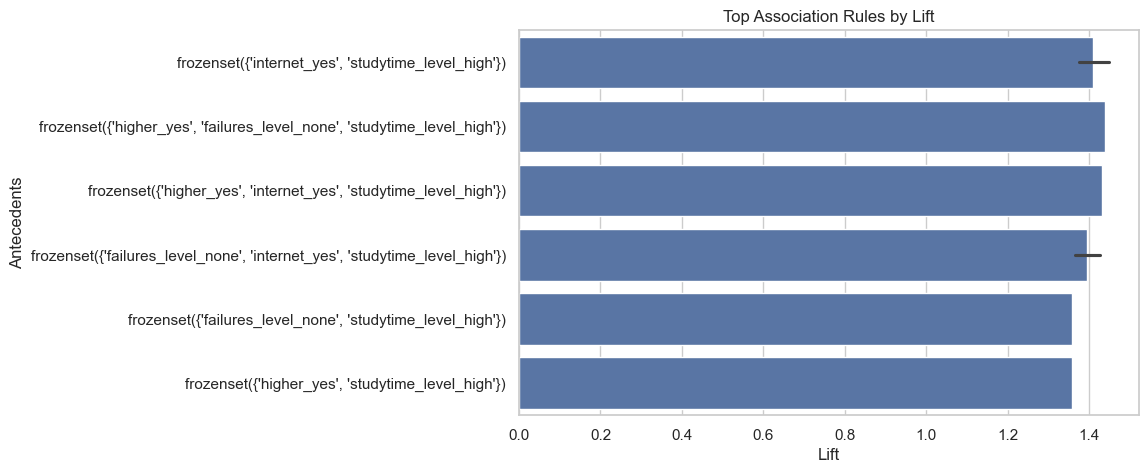

In [27]:
# Plot the top 10 rules by lift
top_rules = rules_pass_fail.head(10).copy()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_rules, x="lift", y=top_rules["antecedents"].astype(str))
plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Antecedents")
plt.show()

### Pattern Mining Interpretation
The association rules reveal combinations of student characteristics that often appear together with pass or fail outcomes.

These patterns can be useful in a real-world setting because they may help educators identify common risk factors or positive learning conditions.

For example, patterns linked to passing may help schools understand which student behaviors and support conditions are most often related to better academic performance.

In [28]:
# Combine all classification results into one table
all_classification_results = pd.concat([
    classification_results,
    tuned_results
], ignore_index=True)

all_classification_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.907692,0.945455
1,Decision Tree,0.876923,0.927928
2,Tuned Decision Tree,0.892308,0.936364


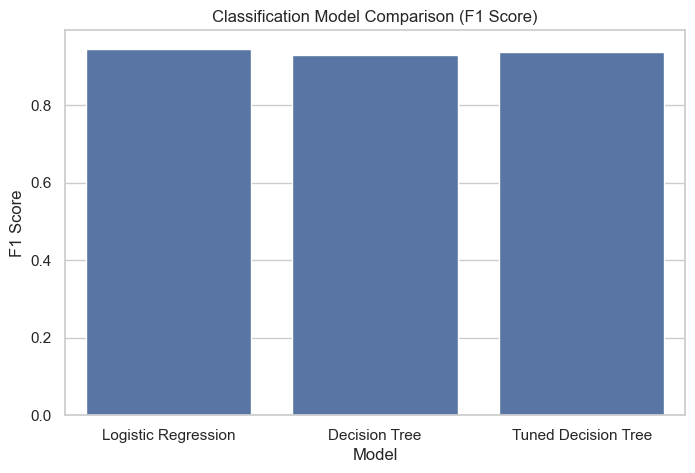

In [29]:
# Compare model F1 scores visually
plt.figure(figsize=(8, 5))
sns.barplot(data=all_classification_results, x="Model", y="F1 Score")
plt.title("Classification Model Comparison (F1 Score)")
plt.show()

### Model Comparison Interpretation
Among the classification models, Logistic Regression performed best overall.

Although tuning improved the Decision Tree, it did not exceed Logistic Regression in Accuracy or F1 Score.

This suggests that Logistic Regression is the most suitable classification model for this dataset in its current form.

### Conclusion
In the deliverable3, I completed classification, clustering, and association rule mining using the student performance dataset.

For classification, I built Logistic Regression and Decision Tree models.
Logistic Regression performed best, with Accuracy = 0.907692 and F1 Score = 0.945455.

I also performed hyperparameter tuning on the Decision Tree model.
The tuned Decision Tree improved over the original model, but it still did not outperform Logistic Regression.

For clustering, I used K-Means with 3 clusters.
The cluster profiles showed meaningful groups of lower-performing, middle-performing, and higher-performing students.

For pattern mining, I used Apriori and found rules that connected student conditions and behaviors with pass/fail outcomes.

Overall, the results show that this dataset can support multiple data mining tasks and provide useful insights for student performance analysis.